In [1]:
%load_ext autoreload
%autoreload 2
from neuropy.analyses import correlations 
import numpy as np
import neuropy.analyses.ms_connectivity as msconn
import seaborn as sns
import matplotlib.pyplot as plt
import time
import subjects
skips = {} # epoch='post'
skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','pyr'))]=np.array([41,98])
skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','inter'))]=np.array([44,21])
skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='I',conn_type=('inter','inter'))]=np.array([[129,125],[21,0],[139,66]])

Error importing CuPy
Error importing CuPy


/Users/selinl/miniforge3/envs/NeuroPy2/lib/python3.11/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [18]:
sess = subjects.nsd.allsess[5]
use_acceleration = False

In [ ]:
cconf=msconn.CCGConfig(use_acceleration=use_acceleration,normalize=msconn.NormalizeBy.BOTH_FRATE)
ndconf=msconn.NeuronsDatasetConfig(seg_stride=60*60*0.5, seg_len=60*60*5, recinfo=sess.recinfo)
nd=msconn.NeuronsDataset(sess,ndconf)

In [ ]:
# get maximum number of significant pairs by using the whole dataset
cd=msconn.CCGDataset(nd,cconf)
cd.get_ccg()

EranConv significant pairs
running eranconv (1st pass)
running spike correlations
spike correlation done
eranconv (1st pass) done
=======RatU_Day2NSD=======
Segment(s) are 9.02h each and contain ['9.02'] hours of actual sleep pyr=174 inter=14 
SLEEP0: E/I pairs 173 / 186 | pyr-pyr/E 07 | pyr-inter/E 97 | inter-inter/I 50 | inter-pyr/I 23 | 
SLEEP1: E/I pairs 174 / 174 | pyr-pyr/E 07 | pyr-inter/E 103 | inter-inter/I 48 | inter-pyr/I 22 | 
SLEEP2: E/I pairs 174 / 160 | pyr-pyr/E 07 | pyr-inter/E 105 | inter-inter/I 44 | inter-pyr/I 22 | 
SLEEP3: E/I pairs 178 / 168 | pyr-pyr/E 06 | pyr-inter/E 109 | inter-inter/I 44 | inter-pyr/I 25 | 
SLEEP4: E/I pairs 176 / 182 | pyr-pyr/E 04 | pyr-inter/E 108 | inter-inter/I 44 | inter-pyr/I 32 | 
SLEEP5: E/I pairs 188 / 184 | pyr-pyr/E 04 | pyr-inter/E 116 | inter-inter/I 46 | inter-pyr/I 29 | 
SLEEP6: E/I pairs 196 / 184 | pyr-pyr/E 04 | pyr-inter/E 122 | inter-inter/I 46 | inter-pyr/I 32 | 
SLEEP7: E/I pairs 203 / 180 | pyr-pyr/E 05 | pyr-inter/E 

In [21]:
cd.set_connection_strengths(method="eran_conv")
cd.set_connectivity()

In [ ]:
cd.reCCG_pair_inds()

running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-inter
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-inter
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-pyr
running spike correlations
spike correlation done
done
recomputed CCG for pairs that had been significant in any segment


In [ ]:
cd.normalize()
cd.set_connection_strengths()
cd.set_connectivity()

In [28]:
cd.example('connectivity')

sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr
[ 26 157]      	In segments [0 1 2 3]           	strengths: [-0.36894398 -0.683915    0.          0.          0.          0.
  0.          0.          0.        ]
[ 28 157]      	In segments [0 1 2]             	strengths: [1.1326522  1.30066161 2.62057862 2.97081365 0.         0.
 0.         0.         0.        ]
[123  31]      	In segments [0]                 	strengths: [1.07800548 3.14545097 1.7446341  1.91676678 2.20329587 2.33919324
 5.04827259 5.05789795 4.84591015]
[147   7]      	In segments [0 1 2 3 4 5 6 7]   	strengths: [ 0.87410763  1.31614038 -0.45471732 -0.43652227  0.          0.76212035
 -0.70112687 -0.64439488 -0.60166908]
[160  46]      	In segments [0 1 2 3 4 5 6 7 8] 	strengths: [ 1.89265212  1.96539195  1.52947957  1.54697714  0.51113803 -0.5253543
 -0.52347723 -0.54180153 -0.54573707]
[165  46]      	In segments [0 1 2 3 4 5 6 7 8] 	strengths: [1.58823737 1.61023999 1.67988003 1.78146211 0.88919115 2.73499591
 3.612

In [27]:
cd.connectivity.keys()

dict_keys([Key(session='RatU_Day2NSD', epoch='post', ref_ind=None, target_ind=None, segment=None, excitability='E', conn_type=('pyr', 'pyr')), Key(session='RatU_Day2NSD', epoch='post', ref_ind=None, target_ind=None, segment=None, excitability='E', conn_type=('pyr', 'inter')), Key(session='RatU_Day2NSD', epoch='post', ref_ind=None, target_ind=None, segment=None, excitability='I', conn_type=('inter', 'inter')), Key(session='RatU_Day2NSD', epoch='post', ref_ind=None, target_ind=None, segment=None, excitability='I', conn_type=('inter', 'pyr'))])

In [34]:
cd.reCCG_timescale(bin_size=1e-4/3)

recalculated CCG from binsize=3.3333333333333335e-05 to binsize=3.3333333333333335e-05
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr
running spike correlations
spike correlation done
done
sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr
sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-inter
sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-inter
sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-pyr
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-inter
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-inter
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-pyr
running spike correlations
spike correlation done
done
rescale completed


In [40]:
cd.set_connection_strengths()
cd.set_connectivity()
cd.example('connectivity')

sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr
[ 26 157]      	In segments [0 1 2 3]           	strengths: [-1. -1.  0.  0.  0.  0.  0.  0.  0.]
[ 28 157]      	In segments [0 1 2]             	strengths: [7. 4. 4. 3. 0. 0. 0. 0. 0.]
[123  31]      	In segments [0]                 	strengths: [1. 2. 1. 1. 1. 1. 2. 2. 2.]
[147   7]      	In segments [0 1 2 3 4 5 6 7]   	strengths: [ 2.  3. -1. -1.  0.  2. -2. -2. -2.]
[160  46]      	In segments [0 1 2 3 4 5 6 7 8] 	strengths: [ 4.  4.  3.  3.  1. -1. -1. -1. -1.]
[165  46]      	In segments [0 1 2 3 4 5 6 7 8] 	strengths: [2. 2. 2. 2. 1. 3. 4. 1. 5.]
[182  10]      	In segments [0 1]               	strengths: [ 1. -1. -1.  4.  3.  3.  3.  3.  3.]
[120  90]      	In segments [1 2 3 8]           	strengths: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
[109 182]      	In segments [2 3 4 5 6 7]       	strengths: [ 2.  3.  0. -1. -1. -1. -1. -1. -2.]
[110   9]      	In segments [7 8]               	strengths: [2. 2. 2. 2. 2. 2. 3. 2. 1.]
[23  9]        	In

In [ ]:
skips = {} # epoch='post'
# skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','pyr'))]=np.array([[109, 182]])
# skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','inter'))]=np.array([[3, 129]])
# skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='I',conn_type=('inter','pyr'))]=np.array([[ 21,  59]])

sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


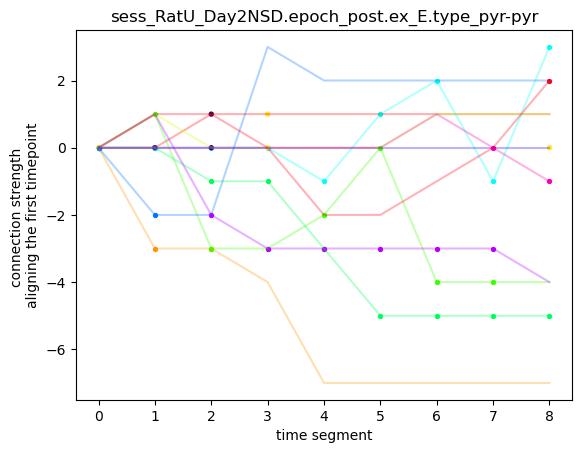

pvals [0.82131542 0.09484687 0.319234   0.0959064  0.18981338 0.23370815
 0.12442333 0.30687609] threshold 0.00625 

mean values [-0.23186945 -1.84482014 -1.04816731 -1.83803656 -1.40674188 -1.26746356
 -1.67725574 -1.0767638 ] 

sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-inter None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


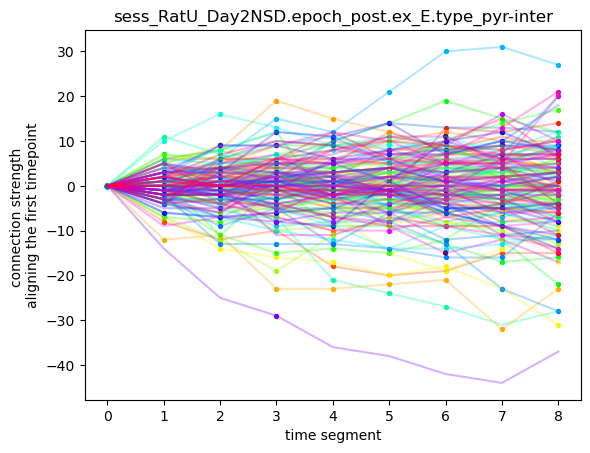

pvals [0.82203449 0.72123047 0.9117201  0.35050243 0.68224749 0.93168425
 0.69472794 0.45871822] threshold 0.00625 

mean values [-0.22530809 -0.35746018  0.11104918 -0.93642379 -0.41016522 -0.08586449
 -0.39317375 -0.7428027 ] 

sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-inter None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


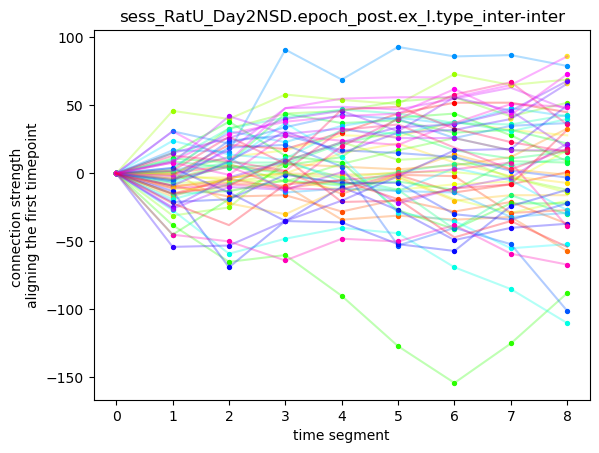

pvals [0.0630283  0.94612522 0.07347403 0.032979   0.1262119  0.28842169
 0.33623916 0.40181902] threshold 0.00625 

mean values [-1.89741059 -0.06788267  1.82473508  2.18744178  1.55277853  1.07195454
  0.97010906  0.84491466] 

sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-pyr None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


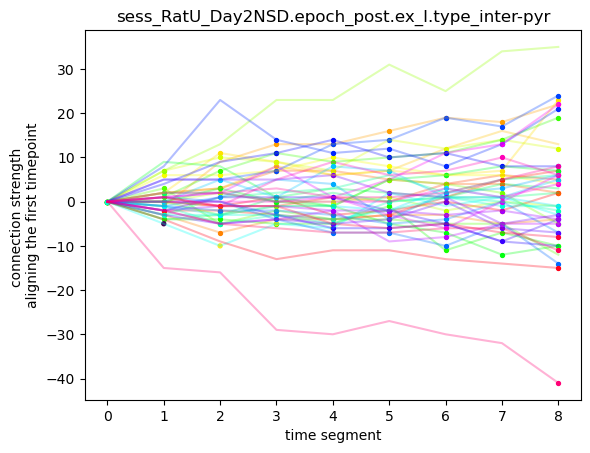

pvals [0.69026741 0.36857683 0.29263059 0.45976393 0.31425082 0.34321327
 0.23603263 0.29322765] threshold 0.00625 

mean values [0.40101282 0.90806497 1.06456183 0.74549688 1.01747187 0.95771487
 1.20065204 1.06322976] 



In [41]:
cd.plot_connection_strengths(show_legend=False,
                                norm_by_total_strength=False,
                                zero_first_timepoint=True,
                                norm_by_n_sess=False,
                                save=False,
                                root="/home/selinali/Documents/NeuroPy/images/conn_strength_1218_RefRateNorm/1-zero_first_timepoint",
                                skips=skips,
                                debug=False)

# individual plots

In [ ]:
_=cd.save_plots(root="~/Documents/NeuroPy/images/ccg_plots_0101",conn_types=[('pyr','inter')])

[Key(session='RatU_Day2NSD', epoch='post', ref_ind=None, target_ind=None, segment=None, excitability='E', conn_type=('pyr', 'inter'))]
Saving plots under ~/Documents/NeuroPy/images/ccg_plots_0101
ccg RatU_Day2NSD ('pyr', 'inter')
0 [ 1 70]
1 [  1 119]
2 [ 2 21]
3 [  2 125]
4 [  3 129]
5 [  4 129]
6 [  4 125]
7 [  5 156]
8 [ 9 42]
9 [10 42]
10 [11 42]
11 [ 13 102]
12 [14 21]
13 [ 16 125]
14 [ 18 125]
